# Trabajo Practico 3
## Visión de Computadora I

### Integrantes 
* Lucia T. Capon Paul
* Cesar Orellana
* Madrid, Martin
* Leandro Britez


### Ejercicios : 

Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en `Material_TPs/TP3/`images a partir del template `Material_TPs/TP3/template`

1. Obtener una detección del logo en cada imagen sin falsos positivos

2. Plantear y validar un algoritmo para múltiples detecciones en la imagen coca_multi.png con el mismo témplate del ítem 1.

3. Generalizar el algoritmo del item 2 para todas las imágenes. 

Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza
de la detección.

## Punto 1

Detección de una instancia del logo por imagen. Comparamos dos de los enfoques vistos en clase con la misma configuración para todas las imágenes:

- Template matching multiescala : matchTemplate sobre la imagen en gris, buscando el mejor score en un rango de escalas.
- SIFT + homografía: correspondencia de descriptores con el ratio de Lowe y findHomography con RANSAC.

Se dibujan los dos resultados lado a lado con su nivel de confianza para comparar cuál detecta mejor en cada imagen.

In [ ]:
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

IMAGE_DIR = Path("images")
TEMPLATE_PATH = Path("template/pattern.png")

image_names = [
    "COCA-COLA-LOGO.jpg",
    "coca_logo_1.png",
    "coca_logo_2.png",
    "coca_multi.png",
    "coca_retro_1.png",
    "coca_retro_2.png",
    "logo_1.png",
]


In [ ]:
def match_template(img_gray, tpl_gray, scales):
    best_det = None
    for s in scales:
        w = int(tpl_gray.shape[1] * s)
        h = int(tpl_gray.shape[0] * s)
        if w < 10 or h < 10 or w > img_gray.shape[1] or h > img_gray.shape[0]:
            continue

        tpl_rs = cv.resize(tpl_gray, (w, h))
        res = cv.matchTemplate(img_gray, tpl_rs, cv.TM_CCOEFF_NORMED)
        _, score, _, loc = cv.minMaxLoc(res)

        if best_det is None or score > best_det[1]:
            best_det = ((loc[0], loc[1], w, h), score)

    return best_det


def match_sift(img_gray, tpl_gray, min_inliers=8):
    sift = cv.SIFT_create()
    kp1, des1 = sift.detectAndCompute(tpl_gray, None)
    kp2, des2 = sift.detectAndCompute(img_gray, None)

    bf = cv.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < 0.75 * n.distance]
    if len(good) < min_inliers:
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
    inliers = int(mask.sum())
    if inliers < min_inliers:
        return None

    h, w = tpl_gray.shape
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    proj = cv.perspectiveTransform(corners, H)
    x, y, bw, bh = cv.boundingRect(np.int32(proj))

    return ((x, y, bw, bh), inliers / len(good))


def best(dets):
    # El template es rojo sobre blanco, pero el logo aparece en ambas
    # polaridades segun la imagen. Probamos las dos versiones y nos
    # quedamos con la mejor deteccion (mayor score).
    dets = [d for d in dets if d is not None]
    return max(dets, key=lambda d: d[1]) if dets else None


def draw_box(img, det, color, label):
    out = img.copy()
    if det is None:
        cv.putText(out, f"{label}: sin deteccion", (10, 30),
                   cv.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        return out

    (x, y, w, h), score = det
    cv.rectangle(out, (x, y), (x + w, y + h), color, 3)
    cv.putText(out, f"{label} conf={score:.2f}", (x, max(20, y - 8)),
               cv.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return out


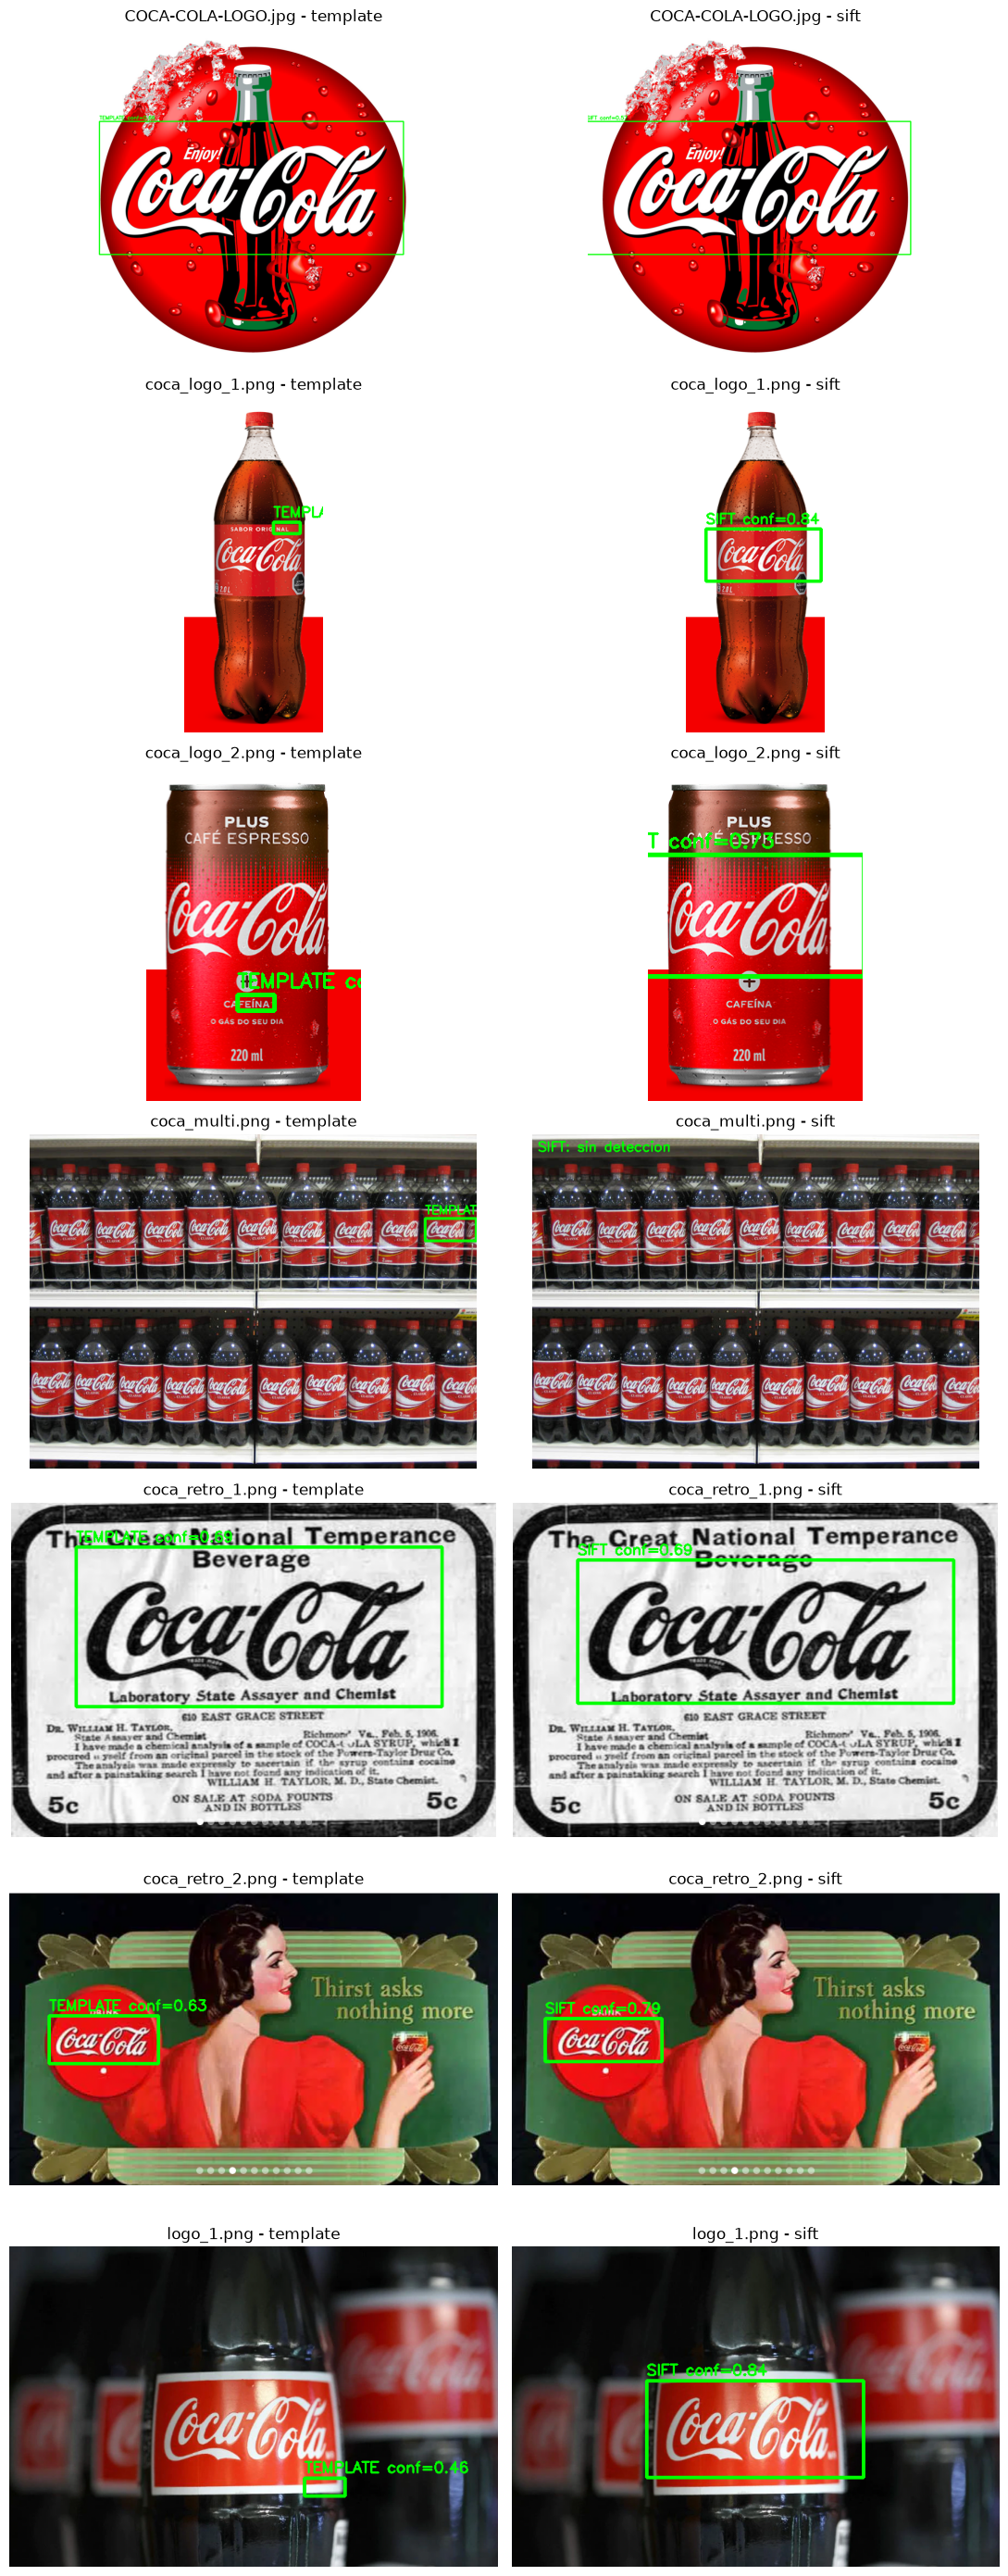

In [ ]:
template = cv.imread(str(TEMPLATE_PATH))
tpl_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
tpl_inv = 255 - tpl_gray
scales = np.linspace(0.1, 3.5, 80)

fig, axes = plt.subplots(len(image_names), 2, figsize=(11, 4 * len(image_names)))

for row, name in enumerate(image_names):
    img = cv.imread(str(IMAGE_DIR / name))
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    det_tpl = best([match_template(img_gray, tpl_gray, scales),
                    match_template(img_gray, tpl_inv, scales)])
    det_sift = best([match_sift(img_gray, tpl_gray),
                     match_sift(img_gray, tpl_inv)])

    axes[row, 0].imshow(cv.cvtColor(draw_box(img, det_tpl, (0, 255, 0), "TEMPLATE"), cv.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"{name} - template")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(cv.cvtColor(draw_box(img, det_sift, (0, 255, 0), "SIFT"), cv.COLOR_BGR2RGB))
    axes[row, 1].set_title(f"{name} - sift")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


- Trabajamos siempre en escala de grises y volvemos a color solo para dibujar la caja.
- El problema principal que hacia que diera pauperrimo era la polaridad de contraste entre el template (oscuro sobre claro) y la mayoria de los logos (claros sobre oscuro). Se resolvio probando el template y su negativo y quedandose con la mejor deteccion.
-Con la polaridad tratada, SIFT da la mejor deteccion unica (6 de 7 imagenes, por lo menos sin falso positivo). De la teoria sabemos que deberìa ser superior por su invariancia en escala y por tolerar curvatura y perspectiva.
- Template matching dentro de todo performa bien en los logos planos, grandes y frontales. Particularmente me sorprendio ganandole a SIFT en la imagen de la gondola de botellas, donde el logo es muy chiquito. En ese caso SIFT no sirve porque mezcla las correspondencias entre logos repetidos. Al haber muchos logos iguales, las correspondencias se reparten entre botellas distintas y RANSAC no logra una homografia coherente.

 Asi que mas o menos que los metodos resultaron **complementarios**!